# ReEntryAI — RL surrogate controller (Colab)

Train a reinforcement-learning bank-angle policy for Orion crew-module entry
guidance and benchmark it against the classical predictor-corrector on a
**frozen, shared** held-out test set.

**All heavy compute lives here (Colab), not on the local machine.** This
notebook covers:

| Phase | What this notebook does |
|---|---|
| 3 | Characterize the classical baseline on the 1,000-case held-out set |
| 4 | Train a PPO policy (`OrionEntryEnv`, dispersed ICs) with W&B logging |
| 5 | Evaluate the trained policy on the **same** held-out set; compare |

The simulator, Gym env (`rl_env.OrionEntryEnv`), dispersion, and test set were
all built in Phases 0–2 and live in the repo. See `docs/rl_mdp_spec.md`.

> **Runtime tip:** set `Runtime → Change runtime type → GPU` and (if you have
> Colab Pro) a **High-RAM / more-CPU** machine. The env step is CPU-bound, so
> the number of vCPUs drives training throughput more than the GPU.

## 0 · Environment setup

In [1]:
# GPU / machine check
import multiprocessing, os
print("CPUs:", multiprocessing.cpu_count())
!nvidia-smi -L || echo "no GPU (CPU-only is fine; training is mostly CPU-bound)"

CPUs: 8
GPU 0: Tesla T4 (UUID: GPU-ff671717-183a-ebf2-5807-8c4deef4d5f6)


In [2]:
# Clone the repo, or pull the latest if it's already here (so code fixes
# pushed to main show up without deleting the runtime).
import os
REPO_URL = "https://github.com/rk0604/ReEntryAI.git"
if not os.path.isdir("ReEntryAI"):
    !git clone --depth 1 {REPO_URL}
else:
    !git -C ReEntryAI pull --ff-only
    print("pulled latest")

Cloning into 'ReEntryAI'...
remote: Enumerating objects: 216, done.
remote: Counting objects: 100% (216/216), done.
remote: Compressing objects: 100% (207/207), done.
remote: Total 216 (delta 12), reused 180 (delta 6), pack-reused 0 (from 0)
Receiving objects: 100% (216/216), 26.10 MiB | 31.94 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [3]:
# Install dependencies
!pip -q install pymsis gymnasium "stable-baselines3>=2.3.0" wandb pandas pyarrow tensorboard
print("deps installed")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 18.1 MB/s eta 0:00:00
deps installed


In [4]:
# Put the simulator package on the path and import the env
import sys, os
SIM_DIR = os.path.abspath("ReEntryAI/StochasticEntrySim")
assert os.path.isdir(SIM_DIR), SIM_DIR
os.chdir(SIM_DIR)                 # configs/ paths resolve relative to here
if SIM_DIR not in sys.path:
    sys.path.insert(0, SIM_DIR)

import numpy as np
import rl_env, mission_config, telemetry
from make_test_set import load_test_set
print("env module loaded:", rl_env.__file__)
print("observation features:", rl_env.OBS_NAMES)

env module loaded: /content/ReEntryAI/StochasticEntrySim/rl_env.py
observation features: ('altitude_norm', 'velocity_norm', 'gamma_norm', 'sin_chi', 'cos_chi', 'range_to_go_norm', 'heading_error_norm', 'cross_track_norm', 'specific_energy_norm', 'sigma_norm', 'heat_margin', 'g_margin', 'hdot_norm')


In [5]:
# Persist everything we generate to Google Drive under MyDrive/ReEntryAI so it
# survives Colab disconnects (and so the cache/resume cells below can reuse it).
# Set USE_DRIVE = False to keep artifacts only in the ephemeral Colab VM.
USE_DRIVE = True
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ARTIFACT_DIR = "/content/drive/MyDrive/ReEntryAI"
else:
    ARTIFACT_DIR = "/content/ReEntryAI_artifacts"

# Subfolders for the different artifact kinds.
DATA_DIR  = f"{ARTIFACT_DIR}/data"          # metrics CSVs (baseline, policy)
CKPT_DIR  = f"{ARTIFACT_DIR}/checkpoints"   # periodic SB3 checkpoints (resume)
MODEL_DIR = f"{ARTIFACT_DIR}/models"        # final saved models
TB_DIR    = f"{ARTIFACT_DIR}/tb"            # tensorboard logs
for d in (ARTIFACT_DIR, DATA_DIR, CKPT_DIR, MODEL_DIR, TB_DIR):
    os.makedirs(d, exist_ok=True)
print("artifacts ->", ARTIFACT_DIR)
!ls -la "{ARTIFACT_DIR}"

Mounted at /content/drive
artifacts -> /content/drive/MyDrive/ReEntryAI
total 16
drwx------ 2 root root 4096 Jun  6 00:02 checkpoints
drwx------ 2 root root 4096 Jun  6 00:02 data
drwx------ 2 root root 4096 Jun  6 00:02 models
drwx------ 2 root root 4096 Jun  6 00:02 tb


## 1 · Sanity check the env

Confirm the Gym contract (SB3's `check_env`) and run one quick episode so we
know imports, spaces, and physics all work before committing compute.

In [6]:
from stable_baselines3.common.env_checker import check_env

env = rl_env.OrionEntryEnv(controller_mode="policy", dispersion=True)
check_env(env, warn=True)        # raises if the Gym API is violated

obs, info = env.reset(seed=0)
print("obs shape:", obs.shape, "| action space:", env.action_space)
done = 0
for _ in range(2000):
    obs, r, term, trunc, info = env.step(env.action_space.sample())
    if term or trunc:
        done = 1; break
print("one random episode ->", info["outcome"],
      "| miss %.1f km | peak_g %.1f | dispersed IC alt=%.0f m"
      % (info["miss_km"], info["peak_g"], info["ic"]["altitude_m"]))

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


obs shape: (13,) | action space: Box(-1.0, 1.0, (1,), float32)
one random episode -> drogue | miss 288.0 km | peak_g 5.2 | dispersed IC alt=120274 m


## 2 · Phase 3 — classical baseline on the held-out set

Run the predictor-corrector over the frozen test set to get the metric
distributions RL must beat. This is embarrassingly parallel; set `WORKERS` to
the number of vCPUs. Each predictor run is ~40 s, so 1,000 cases ≈
`1000 * 40 / WORKERS` seconds.

Start with a subset (`LIMIT`) to estimate wall-time, then run the full set.

In [7]:
import run_baseline, multiprocessing
from pathlib import Path

LIMIT         = 50                 # set to None for the full 1,000-case set
WORKERS       = multiprocessing.cpu_count()
FORCE_BASELINE = False             # True = recompute even if the cache exists
BASE_OUT = Path(DATA_DIR) / "baseline_metrics.csv"

# Cache: skip the (slow) baseline if it's already on Drive.
if BASE_OUT.exists() and not FORCE_BASELINE:
    print(f"[cache] baseline already exists -> {BASE_OUT} (set FORCE_BASELINE=True to redo)")
else:
    run_baseline.run_batch(
        config_path="configs/default.json",
        test_set_path="configs/heldout_testset.csv",
        out_path=BASE_OUT, limit=LIMIT, workers=WORKERS, fast_atmosphere=True)
    print("baseline metrics ->", BASE_OUT)

[cache] baseline already exists -> /content/drive/MyDrive/ReEntryAI/data/baseline_metrics.csv (set FORCE_BASELINE=True to redo)


In [8]:
# Inspect the baseline distribution
import pandas as pd
base_df = pd.read_csv(BASE_OUT)
print("baseline cases:", len(base_df), "| success rate %.1f%%"
      % (100.0 * base_df["success"].mean()))
base_df[["miss_km", "peak_g", "peak_qdot_MWm2", "rcs_fuel_kg"]].describe(
    percentiles=[0.5, 0.9, 0.99])

baseline cases: 1000 | success rate 99.9%


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,miss_km,peak_g,peak_qdot_MWm2,rcs_fuel_kg
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.407503,3.741068,0.439340,95.803964
std,1.945519,0.219865,0.009976,22.220339
min,0.336197,3.485640,0.421580,27.853700
50%,2.050914,3.690237,0.438805,102.235341
90%,3.961406,3.927525,0.453680,117.139698
99%,9.899123,4.798708,0.458705,136.513210
max,27.630651,5.503396,0.460217,165.250270


## 3 · Phase 4 — train the RL policy (PPO)

`OrionEntryEnv` in **policy** mode with **dispersed ICs**. Observations are
already normalized in the env, so no `VecNormalize` is needed. We run several
envs in parallel (`SubprocVecEnv`) because the bottleneck is CPU-side physics.

**Reward:** the env uses **dense progress shaping** (`w_progress_per_km`,
default 0.05) — reward per km of range-to-target closed each step — so the
agent gets a continuous "warmer/colder" signal instead of a single terminal
miss. We pass a stronger `w_range` (terminal miss penalty) than the env default,
and a **now-active fuel penalty** (`w_fuel=0.05`; the env previously hardcoded
the fuel rate to zero, so RCS use was free). Watch `ep/miss_km`; if it stalls,
raise `w_progress_per_km`. Watch `ep/rcs_fuel_kg`; if the policy thrashes the
thrusters, raise `w_fuel`.

> ⚠️ **Changing the reward invalidates old checkpoints.** Use a NEW `RUN_NAME`
> whenever you change reward/hyperparameters, or the resume logic will reload
> the old policy and skip training. (That's why this notebook ships `..._v2`.)

**Interval ablation ladder.** The env exposes three independent interval knobs
(`INTERVAL_OBS`, `INTERVAL_REWARD`, `INTERVAL_SHIELD`, set in the cell below).
Run them as an ablation, each with its own `RUN_NAME`:
1. all off — plain RL baseline
2. `INTERVAL_OBS` — uncertainty-aware policy
3. `+ INTERVAL_REWARD` — penalize the worst-case heat/g
4. `+ INTERVAL_SHIELD` — provably-safe RL (1-step reachability veto)

Watch `ep/interval_violations` (should fall toward zero) and
`ep/shield_intervention_rate` (the policy learning the safe envelope). The
shield makes constraint satisfaction certified rather than hoped-for, which is
the core safety contribution. Note the shield is ~10x slower per step, so use it
once the reward is tuned.

In [9]:
import wandb
wandb.login()        # paste your API key when prompted (or set WANDB_API_KEY)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
/usr/local/lib/python3.12/dist-packages/notebook/utils.py:280: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  return LooseVersion(v) >= LooseVersion(check)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
/usr/local/lib/python3.12/dist-packages/wandb/analytics/sentry.py:269: DeprecationWarning: Read the `app_url` setting from the appropriate Settings object.
  app_url = wandb.util.app_url(tags["base_url"])  # type: ignore[index]
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
wandb: Currently logged in as: anon-user (anon-entity) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [10]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from wandb.integration.sb3 import WandbCallback

N_ENVS   = max(1, multiprocessing.cpu_count())
TOTAL_STEPS = 1_000_000
# Bump this whenever you change the reward/hyperparameters -> fresh checkpoints
# + a clean W&B curve (otherwise resume reloads the old policy and skips).
# v3: fuel penalty is now active in the env (was ignored before), so this is a
# new reward -> new run name.
RUN_NAME = "ppo_orion_entry_v3"

# Stronger miss penalty than the env default for a trainable gradient, plus a
# gentle (now-active) fuel penalty. w_fuel=0.05 keeps the cumulative fuel cost
# ~ -5 over an episode (~95 kg of RCS), small next to the +50 on-target bonus,
# so the policy learns to TARGET first and treats fuel as a secondary nudge.
# Raise w_fuel once miss-distance has converged if you want a leaner policy.
REWARD_WEIGHTS = telemetry.RewardWeights(w_range=1.0e-3, w_fuel=0.05)

# --- Interval-arithmetic ablation switches (the 3 ways intervals enter RL) ---
# Flip these to run the ablation ladder. Use a DISTINCT RUN_NAME per setting.
#   INTERVAL_OBS    : append worst-case interval features to the observation
#   INTERVAL_REWARD : penalize the interval upper bound on heat / g
#   INTERVAL_SHIELD : veto unsafe banks via 1-step interval reachability
INTERVAL_OBS    = False
INTERVAL_REWARD = False
INTERVAL_SHIELD = False

def make_env(rank: int, seed: int = 0):
    def _init():
        import rl_env, telemetry
        e = rl_env.OrionEntryEnv(
            controller_mode="policy", dispersion=True,
            max_episode_steps=1400,
            reward_weights=telemetry.RewardWeights(w_range=1.0e-3, w_fuel=0.05),
            interval_obs=INTERVAL_OBS, interval_reward=INTERVAL_REWARD,
            interval_shield=INTERVAL_SHIELD)
        e = Monitor(e)
        e.reset(seed=seed + rank)
        return e
    return _init

In [11]:
# Custom callback: log per-episode mission metrics (miss, peak-g, success...)
# to W&B, beyond SB3's default reward/length curves -> "log everything".
class MissionMetrics(BaseCallback):
    def _on_step(self) -> bool:
        for info in self.locals.get("infos", []):
            if "episode" in info:                 # episode just ended
                wandb.log({
                    "ep/miss_km":        info.get("miss_km", float("nan")),
                    "ep/peak_g":         info.get("peak_g", float("nan")),
                    "ep/peak_qdot_MWm2": info.get("peak_qdot_MWm2", float("nan")),
                    "ep/rcs_fuel_kg":    info.get("rcs_fuel_kg", float("nan")),
                    "ep/success":        float(info.get("success", False)),
                    "ep/return":         info["episode"]["r"],
                    "ep/length":         info["episode"]["l"],
                    # interval diagnostics (zero unless an interval mode is on)
                    "ep/peak_g_hi":            info.get("peak_g_hi", float("nan")),
                    "ep/interval_violations":  info.get("interval_violations", 0),
                    "ep/shield_intervention_rate": info.get("shield_intervention_rate", 0.0),
                    "global_step":       self.num_timesteps,
                })   # no explicit step= : tensorboard syncing owns the step
        return True

In [12]:
import glob, re

# Resume from W&B (same run id) so curves continue across Colab disconnects.
run = wandb.init(project="ReEntryAI", id=RUN_NAME, name=RUN_NAME, resume="allow",
                 sync_tensorboard=True,
                 config={"total_steps": TOTAL_STEPS, "n_envs": N_ENVS,
                         "algo": "PPO", "w_range": 1.0e-3, "w_fuel": 0.05})

vec = SubprocVecEnv([make_env(i) for i in range(N_ENVS)])

# Cache/resume: pick up the latest checkpoint on Drive if one exists.
def _latest_checkpoint(d):
    cks = glob.glob(f"{d}/ppo_*_steps.zip")
    if not cks:
        return None, 0
    def steps(p):
        m = re.search(r"ppo_(\d+)_steps", p); return int(m.group(1)) if m else 0
    latest = max(cks, key=steps)
    return latest, steps(latest)

ckpt_run_dir = f"{CKPT_DIR}/{RUN_NAME}"
os.makedirs(ckpt_run_dir, exist_ok=True)
resume_path, done_steps = _latest_checkpoint(ckpt_run_dir)

if resume_path:
    print(f"[resume] loading checkpoint {resume_path} ({done_steps} steps done)")
    model = PPO.load(resume_path, env=vec, device="auto",
                     tensorboard_log=f"{TB_DIR}/{RUN_NAME}")
else:
    print("[fresh] no checkpoint found; starting a new run")
    # batch_size divides the rollout buffer (n_steps * N_ENVS) for any vCPU
    # count, so SB3 never silently clamps it; net_arch [128,128] gives the
    # 13-16 dim obs a bit more capacity than the [64,64] default.
    model = PPO("MlpPolicy", vec, verbose=1, device="auto",
                n_steps=1024, batch_size=1024, n_epochs=10,
                gamma=0.999, gae_lambda=0.95, clip_range=0.2,
                ent_coef=0.0, learning_rate=3e-4,
                policy_kwargs=dict(net_arch=[128, 128]),
                tensorboard_log=f"{TB_DIR}/{RUN_NAME}")

ckpt = CheckpointCallback(save_freq=max(1, 50_000 // N_ENVS),
                          save_path=ckpt_run_dir, name_prefix="ppo")
cbs = [WandbCallback(gradient_save_freq=0, verbose=1), MissionMetrics(), ckpt]

remaining = max(0, TOTAL_STEPS - done_steps)
model.learn(total_timesteps=remaining, callback=cbs, progress_bar=True,
            reset_num_timesteps=(resume_path is None))
model.save(f"{MODEL_DIR}/{RUN_NAME}_final")
vec.close()
print("training done ->", f"{MODEL_DIR}/{RUN_NAME}_final.zip")

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,007,616/1,000,000  [ 1:17:50 < 0:00:00 , 224 it/s ]

training done -> /content/drive/MyDrive/ReEntryAI/models/ppo_orion_entry_v3_final.zip


## 4 · Phase 5 — evaluate the policy on the held-out set

Run the trained policy on the **same** frozen ICs the baseline used (via
`reset(options={"ic_override": ...})`), collect the identical metrics, and
compare the two distributions head-to-head. This is the apples-to-apples result.

In [13]:
from stable_baselines3 import PPO
import pandas as pd

EVAL_LIMIT = None                      # None = all 1,000 held-out cases
model = PPO.load(f"{MODEL_DIR}/{RUN_NAME}_final")

# Deterministic env (ICs come from the test set). MUST use the SAME interval
# flags as training so the obs dimension matches and the shield is applied.
eval_env = rl_env.OrionEntryEnv(
    controller_mode="policy", dispersion=False,
    interval_obs=INTERVAL_OBS, interval_reward=INTERVAL_REWARD,
    interval_shield=INTERVAL_SHIELD)
cases = load_test_set("configs/heldout_testset.csv")
if EVAL_LIMIT:
    cases = cases[:EVAL_LIMIT]

rows = []
for i, ic in enumerate(cases):
    obs, info = eval_env.reset(options={"ic_override": ic})
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, r, term, trunc, info = eval_env.step(action)
        done = term or trunc
    rows.append({"idx": i, "outcome": info["outcome"], "miss_km": info["miss_km"],
                 "peak_g": info["peak_g"], "peak_qdot_MWm2": info["peak_qdot_MWm2"],
                 "rcs_fuel_kg": info["rcs_fuel_kg"], "success": int(info["success"]),
                 "interval_violations": info.get("interval_violations", 0),
                 "shield_intervention_rate": info.get("shield_intervention_rate", 0.0)})
    if (i + 1) % 50 == 0:
        print(f"  [{i+1}/{len(cases)}]")

policy_df = pd.DataFrame(rows)
policy_df.to_csv(f"{DATA_DIR}/policy_metrics.csv", index=False)
print("policy metrics -> %s/policy_metrics.csv" % DATA_DIR)
print("policy success rate: %.1f%%" % (100.0 * policy_df["success"].mean()))

  [50/1000]
  [100/1000]
  [150/1000]
  [200/1000]
  [250/1000]
  [300/1000]
  [350/1000]
  [400/1000]
  [450/1000]
  [500/1000]
  [550/1000]
  [600/1000]
  [650/1000]
  [700/1000]
  [750/1000]
  [800/1000]
  [850/1000]
  [900/1000]
  [950/1000]
  [1000/1000]
policy metrics -> /content/drive/MyDrive/ReEntryAI/data/policy_metrics.csv
policy success rate: 1.3%


In [14]:
# Head-to-head comparison (RL vs classical) on identical conditions
import pandas as pd
base_df   = pd.read_csv(f"{DATA_DIR}/baseline_metrics.csv")
policy_df = pd.read_csv(f"{DATA_DIR}/policy_metrics.csv")

def summary(df):
    return pd.Series({
        "success_%":   100.0 * df["success"].mean(),
        "miss_median": df["miss_km"].median(),
        "miss_p90":    df["miss_km"].quantile(0.90),
        "peak_g_med":  df["peak_g"].median(),
        "fuel_med":    df["rcs_fuel_kg"].median(),
    })

cmp = pd.DataFrame({"classical": summary(base_df), "RL": summary(policy_df)})
print(cmp.round(2))

             classical      RL
success_%        99.90    1.30
miss_median       2.05  198.47
miss_p90          3.96  506.70
peak_g_med        3.69    6.62
fuel_med        102.24   11.47


/usr/local/lib/python3.12/dist-packages/google/protobuf/internal/well_known_types.py:178: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  self.FromDatetime(datetime.datetime.utcnow())
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


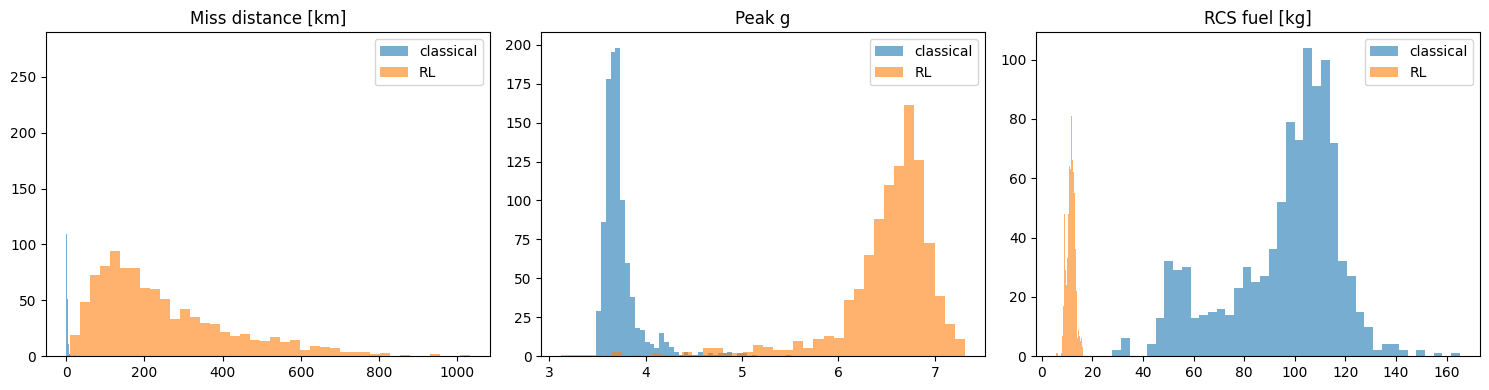

In [15]:
# Distribution plots: RL vs classical
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for col, a, title in zip(
        ["miss_km", "peak_g", "rcs_fuel_kg"], ax,
        ["Miss distance [km]", "Peak g", "RCS fuel [kg]"]):
    a.hist(base_df[col], bins=40, alpha=0.6, label="classical")
    a.hist(policy_df[col], bins=40, alpha=0.6, label="RL")
    a.set_title(title); a.legend()
plt.tight_layout(); plt.show()

---
### Next steps / tuning knobs
- **Reward shaping** — `w_range`, on-target/survive bonuses, optional progress
  shaping. Watch `ep/miss_km` in W&B; if it plateaus high, raise `w_range`.
- **Throughput** — more vCPUs / `N_ENVS`; `LIMIT`/`EVAL_LIMIT` for quick passes.
- **Harder scenario** — swap `config_path="configs/scenario_a_lunar.json"`
  (lunar return) once Scenario B works.
- **Fairness** — both controllers already share ICs, observations, action
  authority, physics, and metrics (see `docs/rl_mdp_spec.md` §5).